[Info] Loaded existing hydrodynamic dataset: data\vlfs4_bc240.nc
Beam end force F_12:
 [ 1.73223759e+05+3.52158903e+05j -5.26761458e-10+2.32472067e-11j
  2.01344754e+06-1.57476221e+06j -4.11179337e-08-3.65783816e-08j
 -1.24173369e+08-8.46787501e+07j  2.60472766e-07-3.58042747e-06j
 -1.73223759e+05-3.52158903e+05j  5.26761458e-10-2.32472067e-11j
 -2.01344754e+06+1.57476221e+06j  4.11179337e-08+3.65783816e-08j
 -2.68351964e+07+2.02785916e+08j -2.99979875e-07+3.58217101e-06j]
Beam end force F_23:
 [-2.51667144e+05-1.69514049e+05j -8.44298303e-10-1.79872403e-10j
  1.07282775e+06+3.57245883e+06j  9.75094194e-08+1.24452021e-08j
  1.15141872e+08-1.76192693e+08j  5.62948385e-06+1.18457263e-06j
  2.51667144e+05+1.69514049e+05j  8.44298303e-10+1.79872403e-10j
 -1.07282775e+06-3.57245883e+06j -9.75094194e-08-1.24452021e-08j
 -1.95603954e+08-9.17417200e+07j -5.69280622e-06-1.19806306e-06j]
Beam end force F_34:
 [ 6.25639600e+05-4.52886571e+05j -3.52862954e-10+2.29258333e-11j
 -2.56437124e+06-3.804

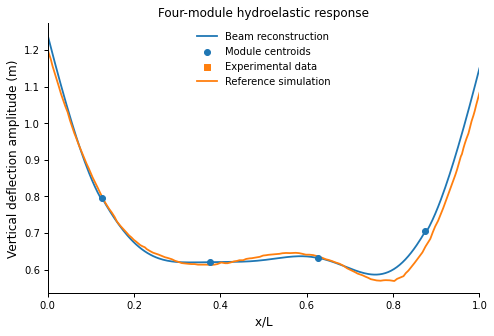

In [ ]:
"""
Single-frequency hydroelastic response of a continuous very large floating structure 
using the Discrete-Module-Beam (DMB) hydroelasticity method.

This script is intended for graduate-level teaching and textbook use.
It demonstrates the following steps:

1. Load or compute hydrodynamic coefficients for a modular floating array.
2. Assemble the equivalent beam stiffness matrix between adjacent modules.
3. Solve the single-frequency hydroelastic response.
4. Recover the vertical deflection curve using the original validated method.
5. Compare the numerical results with reference data in publication-style plots.

Notes
-----
1. This version intentionally removes structural damping.
   The RAO is solved using hydrodynamic coefficients and structural stiffness only.
2. The displacement/deflection recovery routine preserves the original indexing
   logic of the validated code in order to maintain numerical consistency.
3. This is a teaching-oriented single-frequency example, not a general-purpose
   engineering solver.
"""

from __future__ import annotations

import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from scipy.linalg import block_diag

import capytaine as cpt
from capytaine.io.xarray import merge_complex_values
from capytaine.post_pro import rao


# =============================================================================
# 1. User settings
# =============================================================================

USE_SAVED_HYDRO_DATA = True
SAVE_NEW_HYDRO_DATA = False

# =============================================================================
# 2. Physical and numerical parameters
# =============================================================================

# --- Fluid and wave parameters ---
RHO = 1025.0
OMEGA = 0.65
WAVE_DIRECTION = 0.0
SEA_BOTTOM = -58.5

# --- Module properties ---
MODULE_LENGTH = 75.0
MODULE_WIDTH = 60.0
MODULE_HEIGHT = 2.0
MODULE_MASS = 1153125.0
MODULE_CENTER_Z = 0.5

# --- Mesh resolutions ---
FINE_RESOLUTION = (50, 40, 6)     # Used for inertia evaluation
COARSE_RESOLUTION = (32, 30, 6)   # Used for hydrodynamic computation

# --- Array layout ---
N_MODULES = 4
ARRAY_SPACING_X = 37.50

# --- File paths ---
DATA_DIR = Path("data")
REFERENCE_DIR = Path("vlfs_beam_data")
DATASET_FILE = DATA_DIR / "vlfs4_bc240.nc"
REFERENCE_FILE = REFERENCE_DIR / "fu_sim240.txt"

# --- Plot saving ---
SAVE_FIGURE = False
FIGURE_FILE = Path("hydroelastic_comparison.png")
FIGURE_DPI = 600


# =============================================================================
# 3. Hydrodynamic model construction
# =============================================================================

def build_single_module() -> cpt.FloatingBody:
    """
    Build one floating module and evaluate its rigid-body inertia matrix
    and hydrostatic stiffness matrix.

    Returns
    -------
    body : cpt.FloatingBody
        Floating body object containing rigid-body DOFs, inertia matrix,
        and hydrostatic stiffness matrix.
    """
    # A finer mesh is used to obtain a more stable rigid-body inertia matrix.
    fine_body = cpt.RectangularParallelepiped(
        size=(MODULE_LENGTH, MODULE_WIDTH, MODULE_HEIGHT),
        resolution=FINE_RESOLUTION,
        center=(0.0, 0.0, 0.0)
    )
    fine_body.center_of_mass = (0.0, 0.0, 0.0)
    fine_body.mass = MODULE_MASS
    fine_body.add_all_rigid_body_dofs()
    inertia_matrix = fine_body.compute_rigid_body_inertia()

    # A coarser mesh is used in the hydrodynamic calculation.
    body = cpt.RectangularParallelepiped(
        size=(MODULE_LENGTH, MODULE_WIDTH, MODULE_HEIGHT),
        resolution=COARSE_RESOLUTION,
        center=(0.0, 0.0, MODULE_CENTER_Z)
    )
    body.center_of_mass = (0.0, 0.0, MODULE_CENTER_Z)
    body.mass = MODULE_MASS
    body.add_all_rigid_body_dofs()
    body.inertia_matrix = inertia_matrix

    body.keep_immersed_part(free_surface=0.0)
    body.hydrostatic_stiffness = body.compute_hydrostatic_stiffness()
    body.name = f"fpv_{body.mesh.nb_faces:04d}"

    return body


def build_module_array(body: cpt.FloatingBody, n_modules: int = N_MODULES) -> cpt.FloatingBody:
    """
    Build a one-dimensional regular array of floating modules and assemble
    the global inertia and hydrostatic stiffness matrices.

    Parameters
    ----------
    body : cpt.FloatingBody
        Prototype module.
    n_modules : int
        Number of modules in the x direction.

    Returns
    -------
    array_body : cpt.FloatingBody
        Modular array body.
    """
    array_body = body.assemble_regular_array(ARRAY_SPACING_X, (n_modules, 1))

    array_body.inertia_matrix = array_body.add_dofs_labels_to_matrix(
        block_diag(*[body.inertia_matrix for _ in range(n_modules)])
    )
    array_body.hydrostatic_stiffness = array_body.add_dofs_labels_to_matrix(
        block_diag(*[body.hydrostatic_stiffness for _ in range(n_modules)])
    )

    return array_body


def compute_hydrodynamic_dataset(array_body: cpt.FloatingBody) -> xr.Dataset:
    """
    Compute the radiation and diffraction problems at a single wave frequency.

    Parameters
    ----------
    array_body : cpt.FloatingBody
        Modular floating array.

    Returns
    -------
    dataset : xr.Dataset
        Hydrodynamic dataset containing added mass, radiation damping,
        excitation force, inertia matrix, and hydrostatic stiffness.
    """
    problems = [
        cpt.RadiationProblem(
            body=array_body,
            omega=OMEGA,
            rho=RHO,
            sea_bottom=SEA_BOTTOM,
            radiating_dof=dof
        )
        for dof in array_body.dofs
    ]

    problems += [
        cpt.DiffractionProblem(
            omega=OMEGA,
            body=array_body,
            rho=RHO,
            wave_direction=WAVE_DIRECTION,
            sea_bottom=SEA_BOTTOM
        )
    ]

    solver = cpt.BEMSolver()

    start_time = time.perf_counter()
    results = solver.solve_all(problems)
    dataset = cpt.assemble_dataset(results)
    elapsed = time.perf_counter() - start_time

    print(f"Hydrodynamic computation time: {elapsed:.3f} s")
    return dataset


def save_dataset(dataset: xr.Dataset, filepath: Path) -> None:
    """
    Save the complex hydrodynamic dataset to a NetCDF file.

    Parameters
    ----------
    dataset : xr.Dataset
        Hydrodynamic dataset.
    filepath : Path
        Output file path.
    """
    filepath.parent.mkdir(parents=True, exist_ok=True)

    cpt.io.xarray.separate_complex_values(dataset).to_netcdf(
        filepath,
        encoding={
            "radiating_dof": {"dtype": "U"},
            "influenced_dof": {"dtype": "U"}
        }
    )


def load_dataset(filepath: Path) -> xr.Dataset:
    """
    Load a previously saved hydrodynamic dataset from disk.

    Parameters
    ----------
    filepath : Path
        Input file path.

    Returns
    -------
    dataset : xr.Dataset
        Restored complex hydrodynamic dataset.
    """
    return merge_complex_values(xr.open_dataset(filepath))


def get_hydrodynamic_dataset(
    use_saved_dataset: bool = True,
    save_new_dataset: bool = False,
    dataset_file: Path = DATASET_FILE
) -> xr.Dataset:
    """
    Obtain the hydrodynamic dataset either by loading an existing file
    or by recomputing the hydrodynamic coefficients.

    Parameters
    ----------
    use_saved_dataset : bool
        If True, load an existing dataset file.
        If False, recompute the hydrodynamic dataset.
    save_new_dataset : bool
        If True, save the newly computed dataset to disk.
    dataset_file : Path
        Hydrodynamic dataset file path.

    Returns
    -------
    dataset : xr.Dataset
        Hydrodynamic dataset used in the RAO analysis.
    """
    if use_saved_dataset:
        if not dataset_file.exists():
            raise FileNotFoundError(
                f"Hydrodynamic dataset not found: {dataset_file}\n"
                f"Set use_saved_dataset=False to recompute the data."
            )
        dataset = load_dataset(dataset_file)
        print(f"[Info] Loaded existing hydrodynamic dataset: {dataset_file}")
        return dataset

    print("[Info] Recomputing hydrodynamic coefficients...")
    body = build_single_module()
    array_body = build_module_array(body, n_modules=N_MODULES)
    dataset = compute_hydrodynamic_dataset(array_body)

    if save_new_dataset:
        save_dataset(dataset, dataset_file)
        print(f"[Info] Saved new hydrodynamic dataset: {dataset_file}")

    return dataset


# =============================================================================
# 4. Beam stiffness model
# =============================================================================

def create_beam_stiffness_x(length: float = 75.0) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Construct the equivalent beam stiffness matrix in the x direction and
    return its four 6x6 submatrices.

    Parameters
    ----------
    length : float
        Equivalent beam length.

    Returns
    -------
    ke11, ke22, ke21, ke12 : np.ndarray
        Four 6x6 submatrices of the 12x12 beam stiffness matrix.
    """
    E = 1.19e10
    G = E / (2.0 * (1.0 + 0.13))

    # Equivalent section properties retained from the validated original case
    Iy = 40.0
    Iz = (60.0 ** 3) * 2.0 / 12.0
    J = 60.0 * (2.0 ** 3) / 3.0
    A = 120.0

    h1 = E * A / length
    h2 = 12.0 * E * Iz / (length ** 3)
    h3 = 12.0 * E * Iy / (length ** 3)
    h4 = G * J / length
    h5 = 4.0 * E * Iy / length
    h6 = 4.0 * E * Iz / length
    h53 = -6.0 * E * Iy / (length ** 2)
    h62 = 6.0 * E * Iz / (length ** 2)

    ke = np.zeros((12, 12), dtype=float)

    ke[0, 0] = h1
    ke[1, 1] = h2
    ke[2, 2] = h3
    ke[3, 3] = h4
    ke[4, 4] = h5
    ke[5, 5] = h6
    ke[6, 6] = h1
    ke[7, 7] = h2
    ke[8, 8] = h3
    ke[9, 9] = h4
    ke[10, 10] = h5
    ke[11, 11] = h6

    ke[4, 2] = h53
    ke[5, 1] = h62
    ke[10, 8] = -h53
    ke[11, 7] = -h62

    ke[6, 0] = -h1
    ke[7, 1] = -h2
    ke[8, 2] = -h3
    ke[9, 3] = -h4
    ke[10, 4] = h5 / 2.0
    ke[11, 5] = h6 / 2.0
    ke[7, 5] = -h2 * length / 2.0
    ke[8, 4] = -h53
    ke[10, 2] = h53
    ke[11, 1] = h62

    ke += ke.T - np.diag(ke.diagonal())

    ke11 = ke[0:6, 0:6]
    ke22 = ke[6:12, 6:12]
    ke21 = ke[6:12, 0:6]
    ke12 = ke[0:6, 6:12]

    return ke11, ke22, ke21, ke12


def create_beam_element_matrix(length: float = 75.0) -> np.ndarray:
    """
    Construct the full 12x12 beam element stiffness matrix.

    This matrix is used for element end-force recovery.

    Parameters
    ----------
    length : float
        Equivalent beam length.

    Returns
    -------
    ke : np.ndarray
        Full 12x12 beam element stiffness matrix.
    """
    E = 1.19e10
    G = E / (2.0 * (1.0 + 0.13))

    Iy = 40.0
    Iz = (60.0 ** 3) * 2.0 / 12.0
    J = 60.0 * (2.0 ** 3) / 3.0
    A = 120.0

    h1 = E * A / length
    h2 = 12.0 * E * Iz / (length ** 3)
    h3 = 12.0 * E * Iy / (length ** 3)
    h4 = G * J / length
    h5 = 4.0 * E * Iy / length
    h6 = 4.0 * E * Iz / length
    h53 = -6.0 * E * Iy / (length ** 2)
    h62 = 6.0 * E * Iz / (length ** 2)

    ke = np.zeros((12, 12), dtype=float)

    ke[0, 0] = h1
    ke[1, 1] = h2
    ke[2, 2] = h3
    ke[3, 3] = h4
    ke[4, 4] = h5
    ke[5, 5] = h6
    ke[6, 6] = h1
    ke[7, 7] = h2
    ke[8, 8] = h3
    ke[9, 9] = h4
    ke[10, 10] = h5
    ke[11, 11] = h6

    ke[4, 2] = h53
    ke[5, 1] = h62
    ke[10, 8] = -h53
    ke[11, 7] = -h62

    ke[6, 0] = -h1
    ke[7, 1] = -h2
    ke[8, 2] = -h3
    ke[9, 3] = -h4
    ke[10, 4] = h5 / 2.0
    ke[11, 5] = h6 / 2.0
    ke[7, 5] = -h2 * length / 2.0
    ke[8, 4] = -h53
    ke[10, 2] = h53
    ke[11, 1] = h62

    ke += ke.T - np.diag(ke.diagonal())
    return ke


def assemble_global_beam_stiffness(n_modules: int = N_MODULES) -> np.ndarray:
    """
    Assemble the global beam-connection stiffness matrix for a one-dimensional
    modular chain in the x direction.

    Parameters
    ----------
    n_modules : int
        Number of modules.

    Returns
    -------
    ks : np.ndarray
        Global structural stiffness matrix associated with beam connections.
    """
    ke11, ke22, ke21, ke12 = create_beam_stiffness_x()

    total_dofs = 6 * n_modules
    ks = np.zeros((total_dofs, total_dofs), dtype=float)

    ny = 1
    nx = n_modules

    for i in range(1, nx + 1):
        for j in range(1, ny + 1):
            k = nx * (j - 1) + i

            if i == 1:
                ks[6 * k - 6: 6 * k, 6 * k - 6: 6 * k] = ke11
                ks[6 * k - 6: 6 * k, 6 * k: 6 * k + 6] = ke12

            elif i == nx:
                ks[6 * k - 6: 6 * k, 6 * k - 6: 6 * k] = ke22
                ks[6 * k - 6: 6 * k, 6 * k - 12: 6 * k - 6] = ke21

            else:
                ks[6 * k - 6: 6 * k, 6 * k - 6: 6 * k] = ke22 + ke11
                ks[6 * k - 6: 6 * k, 6 * k: 6 * k + 6] = ke12
                ks[6 * k - 6: 6 * k, 6 * k - 12: 6 * k - 6] = ke21

    return ks


# =============================================================================
# 5. RAO solution and post-processing
# =============================================================================

def solve_single_frequency_rao(dataset: xr.Dataset, ks: np.ndarray) -> xr.DataArray:
    """
    Solve the single-frequency RAO of the hydroelastic system.

    Structural damping is intentionally omitted in this version.

    Parameters
    ----------
    dataset : xr.Dataset
        Hydrodynamic dataset.
    ks : np.ndarray
        Structural stiffness matrix from beam connections.

    Returns
    -------
    rao_result : xr.DataArray
        Complex RAO vector.
    """
    rao_result = rao(
        dataset,
        wave_direction=WAVE_DIRECTION,
        stiffness=ks
    )
    return rao_result


def extract_module_heave_amplitudes(
    rao_result: xr.DataArray,
    n_modules: int = N_MODULES
) -> list[float]:
    """
    Extract the heave amplitudes at the centroids of all modules.

    Parameters
    ----------
    rao_result : xr.DataArray
        Complex RAO result.
    n_modules : int
        Number of modules.

    Returns
    -------
    heave_amplitudes : list[float]
        Absolute heave amplitudes of each module.
    """
    heave_amplitudes = []

    for i in range(n_modules):
        dof_name = f"{i}_0__Heave"
        value = np.abs(rao_result.sel(radiating_dof=dof_name).values)
        heave_amplitudes.append(float(value))

    return heave_amplitudes


def compute_element_end_forces(rao_result: xr.DataArray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute the end-force vectors of the three beam elements connecting
    adjacent modules.

    Parameters
    ----------
    rao_result : xr.DataArray
        Complex RAO result.

    Returns
    -------
    f_12, f_23, f_34 : np.ndarray
        End-force vectors for the beam elements between modules 1-2, 2-3, and 3-4.
    """
    x = rao_result.values
    x = x[0]

    x_12 = x[0:12]
    x_23 = x[6:18]
    x_34 = x[12:24]

    ke = create_beam_element_matrix()

    f_12 = np.dot(ke, x_12)
    f_23 = np.dot(ke, x_23)
    f_34 = np.dot(ke, x_34)

    return f_12, f_23, f_34


def compute_global_internal_force(
    rao_result: xr.DataArray,
    ks: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute the global displacement-response vector and the corresponding
    internal-force vector.

    Parameters
    ----------
    rao_result : xr.DataArray
        Complex RAO result.
    ks : np.ndarray
        Global structural stiffness matrix.

    Returns
    -------
    x : np.ndarray
        Complex response vector.
    f : np.ndarray
        Complex internal-force vector.
    """
    x = rao_result.values
    x = x[0]
    f = np.dot(ks, x)
    return x, f


def reconstruct_deflection_original_method(
    x_response: np.ndarray,
    internal_force: np.ndarray
) -> np.ndarray:
    """
    Reconstruct the global vertical deflection curve using the original
    validated piecewise recovery logic.

    Important
    ---------
    This routine intentionally preserves the original index-based logic.
    Although it is not a general beam post-processing routine, it is kept
    unchanged in mathematical form to preserve consistency with the validated case.

    Parameters
    ----------
    x_response : np.ndarray
        Complex displacement-response vector.
    internal_force : np.ndarray
        Complex internal-force vector.

    Returns
    -------
    h : np.ndarray
        Absolute vertical deflection along the global longitudinal coordinate.
    """
    E = 1.19e10
    I = 40.0

    def segment_deflection(n: int) -> np.ndarray:
        if n == 2:
            X = np.linspace(0, 75, 76)
            z = (
                x_response[n]
                - x_response[n + 2] * X
                + internal_force[n + 2] * X**2 / (2 * E * I)
                + internal_force[n] * X**3 / (6 * E * I)
            )

        elif n == 8:
            X = np.linspace(75, 150, 76)
            z = (
                x_response[n - 6]
                - x_response[n - 6 + 2] * X
                + internal_force[n - 6 + 2] * X**2 / (2 * E * I)
                + internal_force[n - 6] * X**3 / (6 * E * I)
                + internal_force[n + 2] * (X - 75)**2 / (2 * E * I)
                + internal_force[n] * (X - 75)**3 / (6 * E * I)
            )

        elif n == 14:
            X = np.linspace(150, 225, 76)
            z = (
                x_response[n - 12]
                - x_response[n - 12 + 2] * X
                + internal_force[n - 12 + 2] * X**2 / (2 * E * I)
                + internal_force[n - 12] * X**3 / (6 * E * I)
                + internal_force[n - 6 + 2] * (X - 75)**2 / (2 * E * I)
                + internal_force[n - 6] * (X - 75)**3 / (6 * E * I)
                + internal_force[n + 2] * (X - 150)**2 / (2 * E * I)
                + internal_force[n] * (X - 150)**3 / (6 * E * I)
            )

        elif n == 20:
            X = np.linspace(0, 37.5, 38)
            z = x_response[n] - x_response[n + 2] * X

        else:
            X = np.linspace(-37.5, 0, 38)
            z = x_response[2] - x_response[4] * X

        return np.abs(z)

    h1 = segment_deflection(1)
    h2 = segment_deflection(2)
    h3 = segment_deflection(8)
    h4 = segment_deflection(14)
    h5 = segment_deflection(20)

    h = np.append(h1, h2)
    h = np.append(h, h3)
    h = np.append(h, h4)
    h = np.append(h, h5)

    return h


# =============================================================================
# 6. Publication-style plotting
# =============================================================================

def set_publication_style() -> None:
    """
    Configure matplotlib parameters for a clean journal-style figure.
    """
    plt.rcParams.update({
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "lines.linewidth": 1.8,
        "axes.linewidth": 1.0,
        "figure.figsize": (7.0, 4.8),
        "savefig.dpi": FIGURE_DPI,
        "savefig.bbox": "tight",
        "mathtext.default": "regular",
    })


def plot_comparison(
    module_heave: list[float],
    deflection_curve: np.ndarray,
    exp_x: list[float] | np.ndarray | None,
    exp_y: list[float] | np.ndarray | None,
    ref_x: np.ndarray,
    ref_y: np.ndarray
) -> None:
    """
    Generate a publication-style comparison plot including:
    - module centroid heave amplitudes,
    - reconstructed beam deflection curve,
    - experimental data (optional),
    - reference numerical simulation.

    Parameters
    ----------
    module_heave : list[float]
        Heave amplitudes at module centroids.
    deflection_curve : np.ndarray
        Reconstructed vertical deflection curve.
    exp_x, exp_y : array-like or None
        Experimental data coordinates. If None, experimental data are omitted.
    ref_x, ref_y : np.ndarray
        Reference simulation data.
    """
    set_publication_style()

    x_curve = np.linspace(0.0, 1.0, 76 * 3 + 38 * 2)
    module_positions = np.array([0.125, 0.375, 0.625, 0.875])

    fig, ax = plt.subplots()

    ax.plot(
        x_curve, deflection_curve,
        label="Beam reconstruction",
        linestyle="-"
    )

    ax.scatter(
        module_positions, module_heave[:4],
        label="Module centroids",
        marker="o",
        s=36,
        zorder=3
    )

    if exp_x is not None and exp_y is not None:
        ax.scatter(
            exp_x, exp_y,
            label="Experimental data",
            marker="s",
            s=28,
            zorder=3
        )

    ax.plot(
        ref_x, ref_y,
        label="Reference simulation",
        linestyle="-"
    )

    ax.set_xlabel(r"$x/L$")
    ax.set_ylabel("Vertical deflection amplitude (m)")
    ax.set_title("Four-module hydroelastic response")

    ax.set_xlim(0.0, 1.0)
    ax.set_xticks(np.linspace(0.0, 1.0, 6))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", length=4.0, width=1.0)

    ax.legend(frameon=False, loc="best")
    fig.tight_layout()

    if SAVE_FIGURE:
        fig.savefig(FIGURE_FILE)
        print(f"[Info] Figure saved to: {FIGURE_FILE}")

    plt.show()


# =============================================================================
# 7. Main procedure
# =============================================================================

def main(use_saved_dataset: bool = True, save_new_dataset: bool = False) -> None:
    """
    Main workflow of the teaching example.

    Steps
    -----
    1. Load or compute the hydrodynamic dataset.
    2. Assemble the global beam stiffness matrix.
    3. Solve the single-frequency RAO.
    4. Extract module heave amplitudes.
    5. Compute beam end forces and global internal forces.
    6. Reconstruct the vertical deflection curve.
    7. Plot comparison results.
    """
    # -------------------------------------------------------------------------
    # Step 1. Hydrodynamic dataset
    # -------------------------------------------------------------------------
    dataset = get_hydrodynamic_dataset(
        use_saved_dataset=use_saved_dataset,
        save_new_dataset=save_new_dataset,
        dataset_file=DATASET_FILE
    )

    # -------------------------------------------------------------------------
    # Step 2. Structural stiffness matrix
    # -------------------------------------------------------------------------
    ks = assemble_global_beam_stiffness(n_modules=N_MODULES)

    # -------------------------------------------------------------------------
    # Step 3. RAO solution
    # -------------------------------------------------------------------------
    rao_result = solve_single_frequency_rao(dataset, ks)

    # -------------------------------------------------------------------------
    # Step 4. Extract centroid heave amplitudes
    # -------------------------------------------------------------------------
    module_heave = extract_module_heave_amplitudes(
        rao_result,
        n_modules=N_MODULES
    )

    # -------------------------------------------------------------------------
    # Step 5. Element end forces and global internal forces
    # -------------------------------------------------------------------------
    f_12, f_23, f_34 = compute_element_end_forces(rao_result)

    print("Beam end force F_12:\n", f_12)
    print("Beam end force F_23:\n", f_23)
    print("Beam end force F_34:\n", f_34)

    x_response, internal_force = compute_global_internal_force(rao_result, ks)

    # -------------------------------------------------------------------------
    # Step 6. Deflection recovery
    # -------------------------------------------------------------------------
    deflection_curve = reconstruct_deflection_original_method(
        x_response=x_response,
        internal_force=internal_force
    )

    # -------------------------------------------------------------------------
    # Step 7. Experimental and reference data
    # -------------------------------------------------------------------------
    exp_x = np.array([
        0.0, 1.2445482e-01, 2.5036640e-01, 3.7538815e-01,
        4.9957065e-01, 6.2579321e-01, 7.5020612e-01,
        8.7496139e-01, 1.0007709e+00
    ])

    exp_y = np.array([
        4.7094526e-01, 2.4020069e-01, 1.3874491e-01,
        1.5849736e-01, 1.2009254e-01, 7.9009332e-02,
        7.9009332e-02, 7.0065913e-02, 1.9744939e-01
    ])

    reference_data = np.loadtxt(REFERENCE_FILE)
    ref_x = reference_data[:, 0]
    ref_y = reference_data[:, 1]

    # If experimental points should be hidden in a specific test,
    # set exp_x = None and exp_y = None before plotting.
    plot_comparison(
        module_heave=module_heave,
        deflection_curve=deflection_curve,
        exp_x=exp_x*0,
        exp_y=exp_y*0,
        ref_x=ref_x,
        ref_y=ref_y
    )


if __name__ == "__main__":
    main(
        use_saved_dataset=USE_SAVED_HYDRO_DATA,
        save_new_dataset=SAVE_NEW_HYDRO_DATA
    )